### Unveiling the Android App Market
#### A Comprehensive Analysis of the Google Play Store Ecosystem

This notebook explores 10,000+ Android apps and 60,000+ user reviews scraped from the Google Play Store. We clean messy real-world data, explore category saturation, analyse ratings, pricing and installs, and run sentiment analysis on user reviews with **VADER**.

####  Project Overview

The Google Play Store hosts millions of apps competing for the same finite pool of user attention, installs, and revenue. For a developer deciding where and how to launch a new app, this landscape is largely a black box. 

This project performs an end-to-end data analysis of the Play Store ecosystem to answer those questions with data rather than guesswork. Starting from two messy, real-world scraped datasets, it:

- Cleans and validates **~10,800 app listings** and **~64,000 user reviews**
- Quantifies category saturation and rating patterns across the store
- Tests whether app size and popularity are actually related
- Breaks down free vs. paid pricing behaviour and estimates revenue by category
- Runs independent sentiment analysis on review text using **VADER** (not the dataset's pre-baked labels)
- Surfaces which categories generate the happiest and unhappiest users
- Closes with three concrete, evidence-backed recommendations for a developer planning a new app launch

#####  Objective

Perform a comprehensive data analysis of the Google Play Store ecosystem by cleaning messy real-world user data, exploring app categories, analysing ratings and pricing trends, and conducting sentiment analysis on user reviews in order to surface actionable insight for someone deciding where and how to launch a new Android app.

#####  Key Questions Answered

1. Which app categories are most crowded, and which offer more breathing room?
2. How are ratings distributed, and which categories rate best on average?
3. Does a smaller app size actually drive more installs?
4. How common are paid apps, what do they typically charge, and which categories generate the most estimated revenue?
5. What do users really feel about the apps they review and does that sentiment vary by category?

#####  Dataset

*Google Play Store Apps* — the widely-used dataset originally published on Kaggle by Lavanya Gupta (a scraped, mid-2018 snapshot of Play Store listings reviews), consisting of two files:
 
`googleplaystore.csv` - 10,841 apps

`googleplaystore_user_reviews.csv`- ~64,295 reviews

#####  Tools & Tech Stack

pandas & numpy for cleaning and analysis 

matplotlib & seaborn for static visualisation 

plotly for the interactive chart 

**VADER** (vaderSentiment) for sentiment analysis 

Jupyter Notebook as the working environment




#### Setup & Data Loading

In [1]:
%pip install pandas numpy matplotlib seaborn plotly


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     --------- ---------------------------- 20.5/80.3 kB 640.0 kB/s eta 0:00:01
     ----------------------------------- ---- 71.7/80.3 kB 1.3 MB/s eta 0:00:01
     -------------------------------------- 80.3/80.3 kB 897.7 kB/s eta 0:00:00
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/121.0 kB ? eta -:--:--
     ---------------------------------------- 121.0/121.0 kB ? eta 0:00:00
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached narwhals-2.25.0-py3-none-any.whl.metadata (15 kB)
   ---------------------------------------- 0.0/10.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/10.0 MB 15.9 MB/s eta 0:00:01
   --- ------------------------------------ 0.9/10.0 MB 11.3 MB

In [2]:
%pip install vaderSentiment

  Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl.metadata (572 bytes)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
     ---------------------------------------- 0.0/46.7 kB ? eta -:--:--
     ---------------------------------------- 0.0/46.7 kB ? eta -:--:--
     -------- ------------------------------- 10.2/46.7 kB ? eta -:--:--
     -------- ------------------------------- 10.2/46.7 kB ? eta -:--:--
     ---------------- --------------------- 20.5/46.7 kB 217.9 kB/s eta 0:00:01
     ---------------- --------------------- 20.5/46.7 kB 217.9 kB/s eta 0:00:01
     -------------------------------------- 46.7/46.7 kB 234.0 kB/s eta 0:00:00
  Using cached idna-3.19-py3-none-any.whl.metadata (9.2 kB)
  Using cached urllib3-2.7.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached certifi-2026.7.22-py3-none-any.whl.metadata (2.5 kB)
Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl (125 kB)
Using cached requests-2.34.2-py3-none-any.whl (73 kB)
Using cached cer


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import plotly.express as px
import plotly.io as pio
from IPython.display import display, HTML

%matplotlib inline
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', 30)

PALETTE = sns.color_palette("viridis", 12)


In [8]:
apps_raw = pd.read_csv('../data/googleplaystore.csv')
reviews_raw = pd.read_csv('../data/googleplaystore_user_reviews.csv')

print(f"Apps dataset:    {apps_raw.shape[0]:,} rows x {apps_raw.shape[1]} columns")
print(f"Reviews dataset: {reviews_raw.shape[0]:,} rows x {reviews_raw.shape[1]} columns")
apps_raw.head(10)


Apps dataset:    10,841 rows x 13 columns
Reviews dataset: 64,295 rows x 5 columns


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
5,Paper flowers instructions,ART_AND_DESIGN,4.4,167,5.6M,"50,000+",Free,0,Everyone,Art & Design,"March 26, 2017",1.0,2.3 and up
6,Smoke Effect Photo Maker - Smoke Editor,ART_AND_DESIGN,3.8,178,19M,"50,000+",Free,0,Everyone,Art & Design,"April 26, 2018",1.1,4.0.3 and up
7,Infinite Painter,ART_AND_DESIGN,4.1,36815,29M,"1,000,000+",Free,0,Everyone,Art & Design,"June 14, 2018",6.1.61.1,4.2 and up
8,Garden Coloring Book,ART_AND_DESIGN,4.4,13791,33M,"1,000,000+",Free,0,Everyone,Art & Design,"September 20, 2017",2.9.2,3.0 and up
9,Kids Paint Free - Drawing Fun,ART_AND_DESIGN,4.7,121,3.1M,"10,000+",Free,0,Everyone,Art & Design;Creativity,"July 3, 2018",2.8,4.0.3 and up


In [9]:
reviews_raw.head(10)

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000
5,10 Best Foods for You,Best way,Positive,1.00,0.300000
6,10 Best Foods for You,Amazing,Positive,0.60,0.900000
7,10 Best Foods for You,NaN,NaN,NaN,NaN
8,10 Best Foods for You,"Looking forward app,",Neutral,0.00,0.000000
9,10 Best Foods for You,It helpful site ! It help foods get !,Neutral,0.00,0.000000


In [10]:
apps_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


#### Data Cleaning

Real-world scraped data is messy. Issues we need to fix in the **apps** dataset:

- `Installs` is stored as text like `"10,000+"` instead of a number.
- `Price` is stored as text like `"$4.99"` instead of a number.
- `Size` mixes `"19M"`, `"800k"` and `"Varies with device"`.
- `Reviews` is stored as text/object instead of an integer.
- 1,181 apps appear more than once (re-scraped at different times) — we keep the most complete/recent record.
- `Rating` has 1,474 missing values (~13.6%) — we leave these as `NaN` and exclude them from rating-specific analyses rather than guessing a value.


In [15]:
# Count nulls by column in the apps dataset
apps_raw.isna().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [22]:
apps = apps_raw.copy()

# Drop the known corrupt row where columns are shifted 
corrupt_mask = apps['Category'] == '1.9'
print(f"Dropping {corrupt_mask.sum()} corrupt row(s)")
apps = apps[~corrupt_mask].copy()

# Fix the single missing 'Type' using Price (0 => Free)
apps['Type'] = apps.apply(
    lambda r: 'Free' if (pd.isna(r['Type']) and str(r['Price']) == '0') else r['Type'], axis=1
)

# Installs: "10,000+" -> 10000 (int) 
apps['Installs'] = (
    apps['Installs'].astype(str).str.replace('[+,]', '', regex=True)
)
apps['Installs'] = pd.to_numeric(apps['Installs'], errors='coerce').astype('Int64')

# Price: "$4.99" -> 4.99 (float) 
apps['Price'] = apps['Price'].astype(str).str.replace('$', '', regex=False)
apps['Price'] = pd.to_numeric(apps['Price'], errors='coerce')

# Reviews: object -> int 
apps['Reviews'] = pd.to_numeric(apps['Reviews'], errors='coerce').astype('Int64')

# Size: "19M" -> 19.0 (MB), "800k" -> 0.78 (MB), "Varies with device" -> NaN 
def clean_size(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x == 'Varies with device':
        return np.nan
    try:
        if x.endswith('M'):
            return float(x[:-1])
        elif x.lower().endswith('k'):
            return float(x[:-1]) / 1024
        return np.nan
    except ValueError:
        return np.nan

apps['Size_MB'] = apps['Size'].apply(clean_size)

# Last Updated -> datetime 
apps['Last Updated'] = pd.to_datetime(apps['Last Updated'], errors='coerce')

# Content Rating: fill the 1 missing value with the mode 
apps['Content Rating'] = apps['Content Rating'].fillna(apps['Content Rating'].mode()[0])

print("Cleaned dtypes:")
print(apps[['Rating','Reviews','Size_MB','Installs','Type','Price']].dtypes)


Dropping 1 corrupt row(s)
Cleaned dtypes:
Rating      float64
Reviews       Int64
Size_MB     float64
Installs      Int64
Type            str
Price       float64
dtype: object


In [23]:
# Remove duplicate app entries, keeping the record with the most reviews 
before = apps.shape[0]
apps = apps.sort_values('Reviews', ascending=False).drop_duplicates(subset='App', keep='first')
apps = apps.reset_index(drop=True)
after = apps.shape[0]
print(f"Removed {before - after:,} duplicate rows -> {after:,} unique apps remain")

print("\nRemaining nulls:")
print(apps.isna().sum()[apps.isna().sum() > 0])


Removed 1,181 duplicate rows -> 9,659 unique apps remain

Remaining nulls:
Rating         1463
Current Ver       8
Android Ver       2
Size_MB        1228
dtype: int64


#### Cleaning the reviews dataset

Almost 42% of the reviews file is empty rows (apps with no review text at all just placeholders). We drop those and remove exact duplicates.

In [24]:
reviews = reviews_raw.copy()
before = reviews.shape[0]
reviews = reviews.dropna(subset=['Translated_Review']).drop_duplicates().reset_index(drop=True)
after = reviews.shape[0]
print(f"Reviews: {before:,} -> {after:,} after dropping empty/duplicate rows ({(before-after)/before:.1%} removed)")
reviews.head()


Reviews: 64,295 -> 29,692 after dropping empty/duplicate rows (53.8% removed)


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
3,10 Best Foods for You,Best idea us,Positive,1.00,0.300000
4,10 Best Foods for You,Best way,Positive,1.00,0.300000


#### Category Analysis

How are apps distributed across the Play Store's categories, and which categories are the most saturated (i.e. have the most competing apps)?

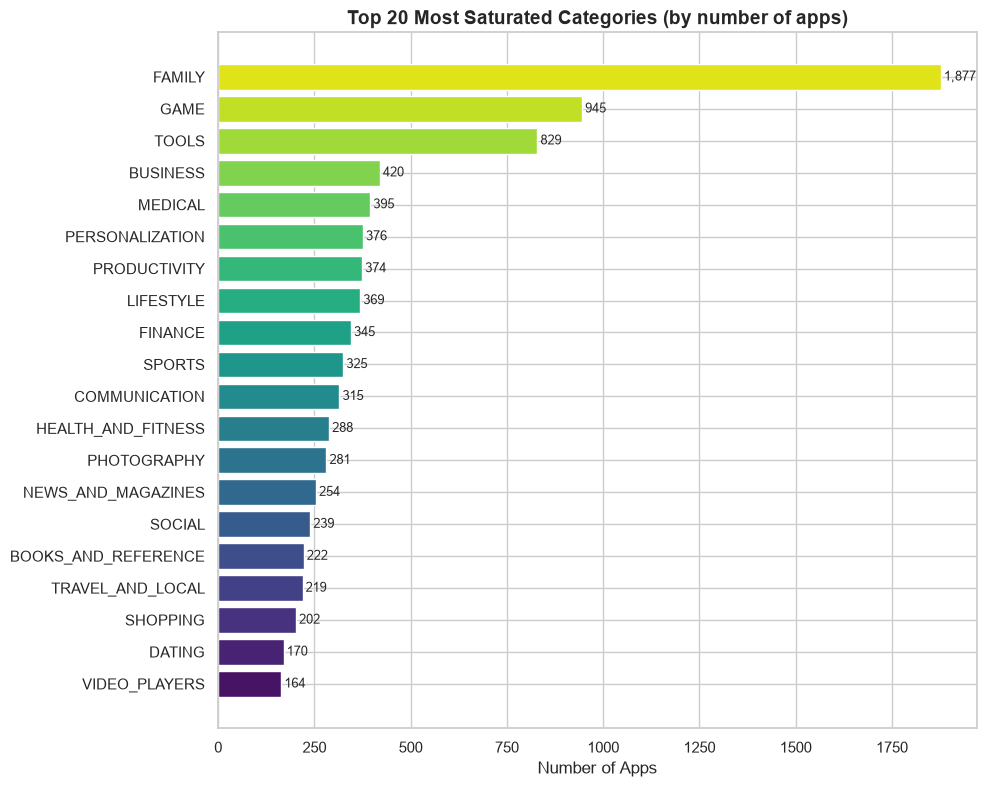

Total categories: 33

Most saturated: FAMILY (1,877 apps, 19.4% of the store)
Least saturated: BEAUTY (53 apps)


In [25]:
cat_counts = apps['Category'].value_counts()

fig, ax = plt.subplots(figsize=(10, 8))
top_n = 20
bars = ax.barh(cat_counts.head(top_n).index[::-1], cat_counts.head(top_n).values[::-1],
                color=sns.color_palette("viridis", top_n))
ax.set_title(f'Top {top_n} Most Saturated Categories (by number of apps)', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Apps')
for bar in bars:
    w = bar.get_width()
    ax.text(w + 8, bar.get_y() + bar.get_height()/2, f'{int(w):,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print(f"Total categories: {apps['Category'].nunique()}")
print(f"\nMost saturated: {cat_counts.index[0]} ({cat_counts.iloc[0]:,} apps, "
      f"{cat_counts.iloc[0]/len(apps):.1%} of the store)")
print(f"Least saturated: {cat_counts.index[-1]} ({cat_counts.iloc[-1]} apps)")


**Observation:** FAMILY and GAME dominate the store by sheer app count,together they account for a large share of all listings, meaning a new app here faces intense discoverability competition. Categories like `BEAUTY`, `EVENTS`, `PARENTING` and `COMICS` have far fewer competing apps that are easier to stand out in, though also signalling smaller market demand.

#### Ratings Analysis

What does the overall distribution of app ratings look like, and which categories rate best on average?

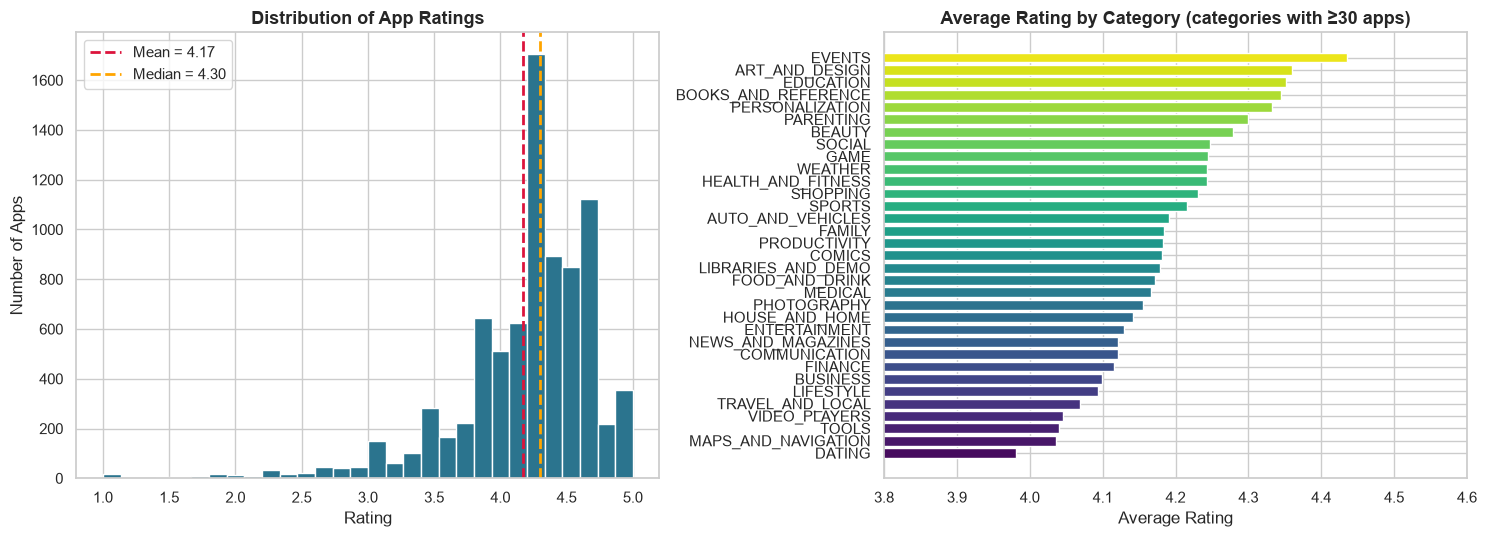

Overall average rating: 4.17 / 5.0
Highest-rated category: EVENTS (4.44)
Lowest-rated category:  DATING (3.98)


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Distribution of ratings
axes[0].hist(apps['Rating'].dropna(), bins=30, color=PALETTE[4], edgecolor='white')
axes[0].axvline(apps['Rating'].mean(), color='crimson', linestyle='--', linewidth=2,
                 label=f"Mean = {apps['Rating'].mean():.2f}")
axes[0].axvline(apps['Rating'].median(), color='orange', linestyle='--', linewidth=2,
                 label=f"Median = {apps['Rating'].median():.2f}")
axes[0].set_title('Distribution of App Ratings', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Number of Apps')
axes[0].legend()

# Average rating by category (min 30 apps to be meaningful)
min_apps = 30
valid_cats = cat_counts[cat_counts >= min_apps].index
avg_rating = apps[apps['Category'].isin(valid_cats)].groupby('Category')['Rating'].mean().sort_values(ascending=False)

colors = sns.color_palette("viridis", len(avg_rating))
axes[1].barh(avg_rating.index[::-1], avg_rating.values[::-1], color=colors)
axes[1].set_title(f'Average Rating by Category (categories with \u2265{min_apps} apps)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Rating')
axes[1].set_xlim(3.8, 4.6)

plt.tight_layout()
plt.show()

print(f"Overall average rating: {apps['Rating'].mean():.2f} / 5.0")
print(f"Highest-rated category: {avg_rating.index[0]} ({avg_rating.iloc[0]:.2f})")
print(f"Lowest-rated category:  {avg_rating.index[-1]} ({avg_rating.iloc[-1]:.2f})")


**Observation:** Ratings are heavily left-skewed.Most apps sit between 4.0 and 4.5, and very few apps are rated below 3.0 (unpopular/broken apps tend to simply get abandoned/removed rather than accumulate 1-star ratings). `EVENTS`, `ART_AND_DESIGN`, `EDUCATION` and `BOOKS_AND_REFERENCE` rate best on average.They are often niche, well-scoped utility apps.

#### Size vs. Installs

Does a smaller app size correlate with more installs (e.g. because it's more accessible on low-end devices / limited data plans)?

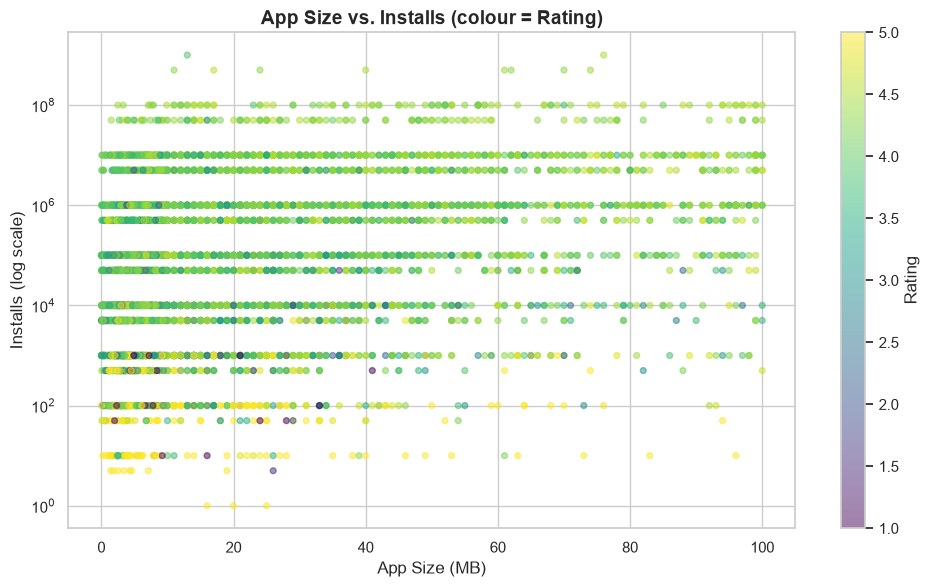

Pearson correlation (Size vs raw Installs):      0.134
Pearson correlation (Size vs log10(Installs)):   0.299


In [27]:
valid = apps.dropna(subset=['Size_MB', 'Installs'])
valid = valid[valid['Installs'] > 0]

corr_linear = valid['Size_MB'].corr(valid['Installs'])
corr_log = valid['Size_MB'].corr(np.log10(valid['Installs']))

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(valid['Size_MB'], valid['Installs'], c=valid['Rating'],
                      cmap='viridis', alpha=0.5, s=18)
ax.set_yscale('log')
ax.set_xlabel('App Size (MB)')
ax.set_ylabel('Installs (log scale)')
ax.set_title('App Size vs. Installs (colour = Rating)', fontsize=14, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Rating')
plt.tight_layout()
plt.show()

print(f"Pearson correlation (Size vs raw Installs):      {corr_linear:.3f}")
print(f"Pearson correlation (Size vs log10(Installs)):   {corr_log:.3f}")


**Observation:** The correlation between app size and installs is weak (roughly **0.13** on the raw scale, ~**0.30** against log-installs). Size alone is not a strong driver of popularity, the most-installed apps span the full range of sizes, from a few MB up to 100 MB. Being small helps a little (log-installs correlation is modestly positive) but is nowhere near as important as category, marketing, or being a Free app. This is a useful myth-buster for a developer worried about app size.

#### Pricing Analysis

Free vs. Paid split, the price distribution among paid apps, and a rough revenue estimate by category.

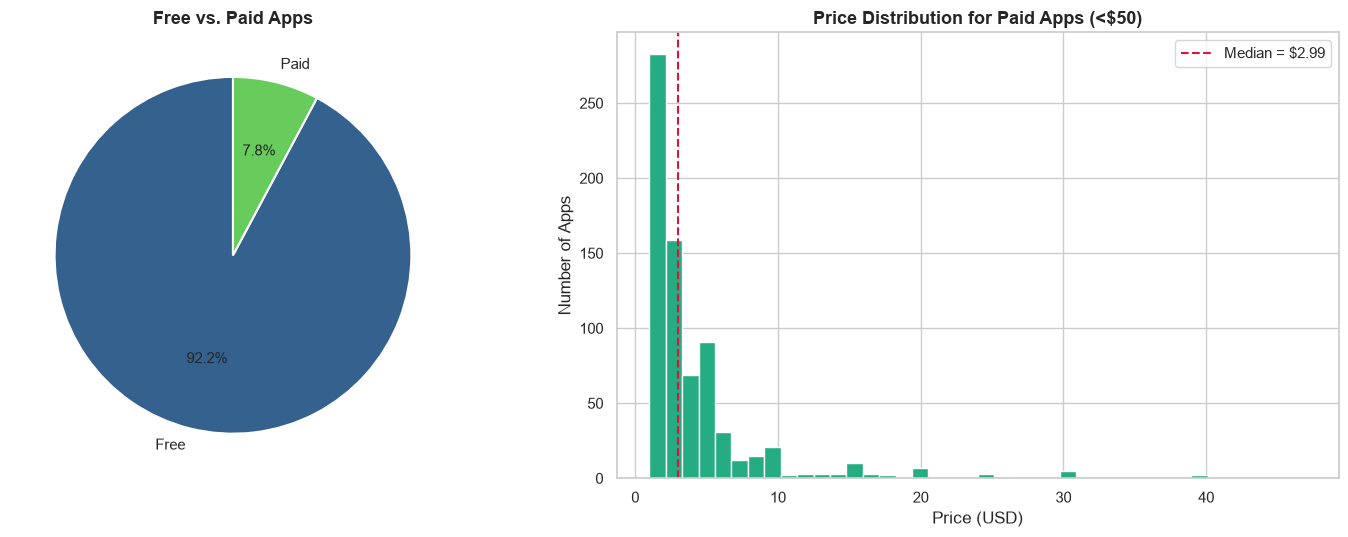

Free apps: 8,905 (92.2%)  |  Paid apps: 754 (7.8%)
Median paid app price: $2.99
Most expensive apps in the dataset:
                     App  Category  Price
I'm Rich - Trump Edition LIFESTYLE 400.00
               I am rich LIFESTYLE 399.99
       I Am Rich Premium   FINANCE 399.99
          I am Rich Plus    FAMILY 399.99
              💎 I'm rich LIFESTYLE 399.99


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

type_counts = apps['Type'].value_counts()
axes[0].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
            colors=[PALETTE[3], PALETTE[9]], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Free vs. Paid Apps', fontsize=13, fontweight='bold')

paid = apps[(apps['Type'] == 'Paid') & (apps['Price'] > 0) & (apps['Price'] < 50)]
axes[1].hist(paid['Price'], bins=40, color=PALETTE[7], edgecolor='white')
axes[1].axvline(paid['Price'].median(), color='crimson', linestyle='--',
                  label=f"Median = ${paid['Price'].median():.2f}")
axes[1].set_title('Price Distribution for Paid Apps (<$50)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Price (USD)')
axes[1].set_ylabel('Number of Apps')
axes[1].legend()

plt.tight_layout()
plt.show()

n_free, n_paid = type_counts.get('Free', 0), type_counts.get('Paid', 0)
print(f"Free apps: {n_free:,} ({n_free/len(apps):.1%})  |  Paid apps: {n_paid:,} ({n_paid/len(apps):.1%})")
print(f"Median paid app price: ${apps[apps['Type']=='Paid']['Price'].median():.2f}")
print(f"Most expensive apps in the dataset:")
print(apps.nlargest(5, 'Price')[['App','Category','Price']].to_string(index=False))


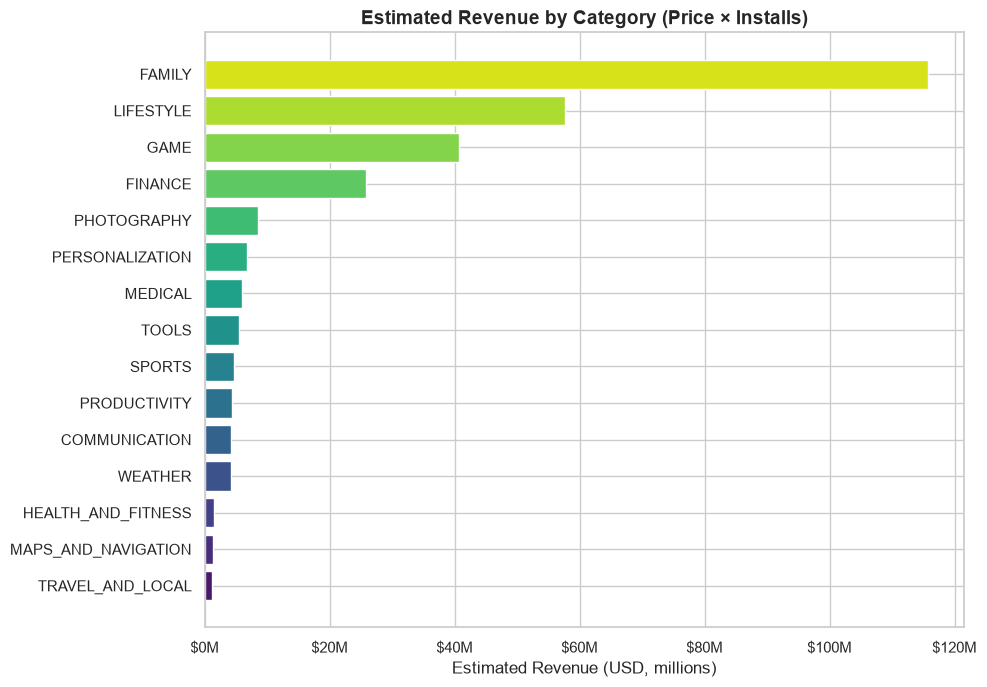

Top 5 categories by estimated revenue:
Category
FAMILY         115.7M
LIFESTYLE       57.6M
GAME            40.7M
FINANCE         25.7M
PHOTOGRAPHY      8.5M
Name: Revenue_est, dtype: str


In [ ]:
# Rough revenue estimate = Price x Installs (assumes 1 install = 1 purchase; a simplification,
# since real Play Store pricing includes trials/refunds/regional pricing, but useful as a relative proxy)
apps['Revenue_est'] = apps['Price'] * apps['Installs']
revenue_by_cat = apps.groupby('Category')['Revenue_est'].sum().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(revenue_by_cat.index[::-1], (revenue_by_cat.values[::-1]) / 1e6,
                color=sns.color_palette("viridis", 15))
ax.set_xlabel('Estimated Revenue (USD, millions)')
ax.set_title('Estimated Revenue by Category (Price \u00d7 Installs)', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
plt.tight_layout()
plt.show()

print("Top 5 categories by estimated revenue:")
print((revenue_by_cat.head(5) / 1e6).round(1).astype(str) + 'M')


**Observation:** ~92% of apps are free.Paid apps are a small minority, typically priced between \$0.99 and \$4.99. `FAMILY`, `LIFESTYLE` and `GAME` lead on estimated revenue (this is a **rough proxy**, treating each install as one purchase; real-world paid conversion, refunds, and regional pricing would change the picture, but it's useful for relative comparison across categories).

#### Sentiment Analysis on User Reviews (VADER)

We use **VADER** (Valence Aware Dictionary and sEntiment Reasoner) — a lexicon and rule-based sentiment tool tuned specifically for short, informal, social-media-style text, which makes it a great fit for app reviews. No training required: it returns a `compound` score from -1 (most negative) to +1 (most positive) for each review.

Classification rule (VADER's standard thresholds):
- `compound >= 0.05` &rarr; **Positive**
- `compound <= -0.05` &rarr; **Negative**
- otherwise &rarr; **Neutral**


In [29]:
analyzer = SentimentIntensityAnalyzer()

reviews['vader_compound'] = reviews['Translated_Review'].apply(
    lambda t: analyzer.polarity_scores(str(t))['compound']
)

def classify(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    return 'Neutral'

reviews['vader_sentiment'] = reviews['vader_compound'].apply(classify)

sentiment_counts = reviews['vader_sentiment'].value_counts()
print(sentiment_counts)
print()
print((sentiment_counts / len(reviews) * 100).round(1).astype(str) + '%')


vader_sentiment
Positive    20195
Negative     5867
Neutral      3630
Name: count, dtype: int64

vader_sentiment
Positive    68.0%
Negative    19.8%
Neutral     12.2%
Name: count, dtype: str


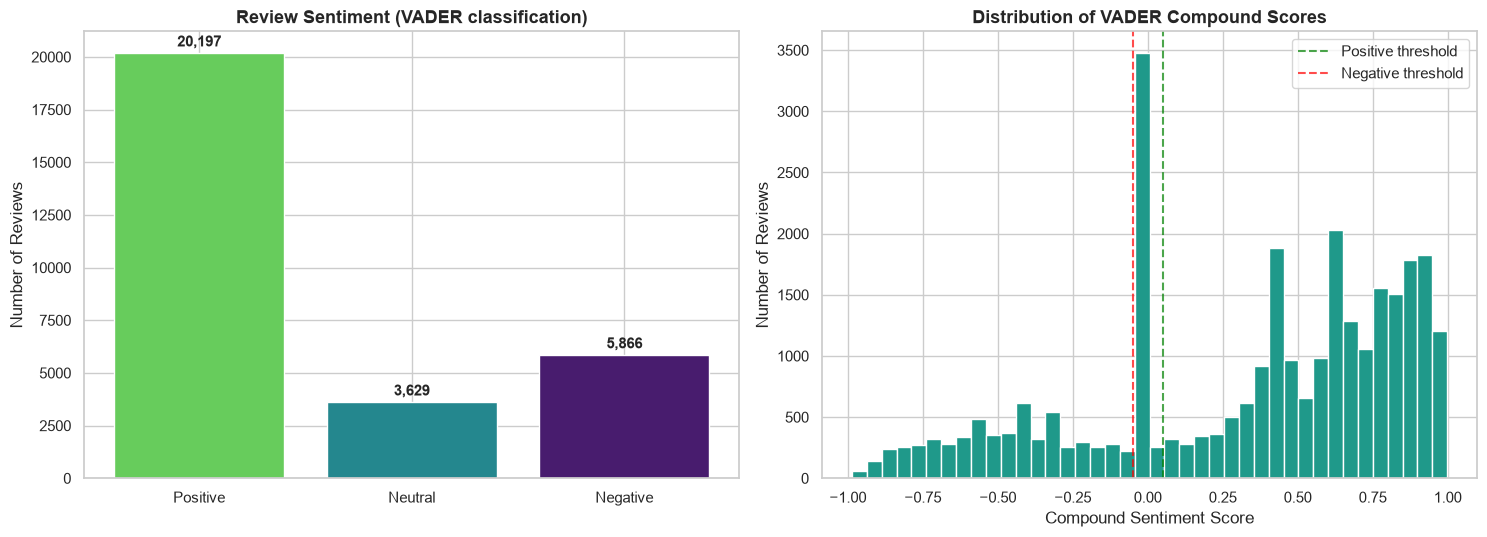


Example positive review: Who ever hates game, means lost brains!!! It's soo cute own, I say, multiplayer best! But thing let's swears...I like that. ALSO big talk FOR 3 HOURS 

Example negative review: »TOO BRIGHT!… NIGHT MODE, PLEASE. HOW MANY REQUESTS DO Y'ALL NEED BEFORE YOU IMPLEMENT A DAMN DARK THEME?!!« Also, I can't help feel like lacking lot 


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

colors_map = {'Positive': PALETTE[9], 'Neutral': PALETTE[5], 'Negative': PALETTE[0]}
order = ['Positive', 'Neutral', 'Negative']
counts_ordered = sentiment_counts.reindex(order)

axes[0].bar(order, counts_ordered.values, color=[colors_map[o] for o in order], edgecolor='white')
axes[0].set_title('Review Sentiment (VADER classification)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Reviews')
for i, v in enumerate(counts_ordered.values):
    axes[0].text(i, v + 300, f'{v:,}', ha='center', fontweight='bold')

axes[1].hist(reviews['vader_compound'], bins=40, color=PALETTE[6], edgecolor='white')
axes[1].axvline(0.05, color='green', linestyle='--', alpha=0.7, label='Positive threshold')
axes[1].axvline(-0.05, color='red', linestyle='--', alpha=0.7, label='Negative threshold')
axes[1].set_title('Distribution of VADER Compound Scores', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Compound Sentiment Score')
axes[1].set_ylabel('Number of Reviews')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nExample positive review:", reviews.loc[reviews['vader_compound'].idxmax(), 'Translated_Review'][:150])
print("\nExample negative review:", reviews.loc[reviews['vader_compound'].idxmin(), 'Translated_Review'][:150])


**Observation:** The large majority of reviews (roughly two-thirds) are positive.Users who bother leaving a review tend to do so either because they love the app or are frustrated by it, with negative reviews (~1 in 5) outnumbering strictly neutral ones.

#### Sentiment by Category

Merging reviews with the cleaned apps table lets us see which categories generate the happiest and unhappiest users.

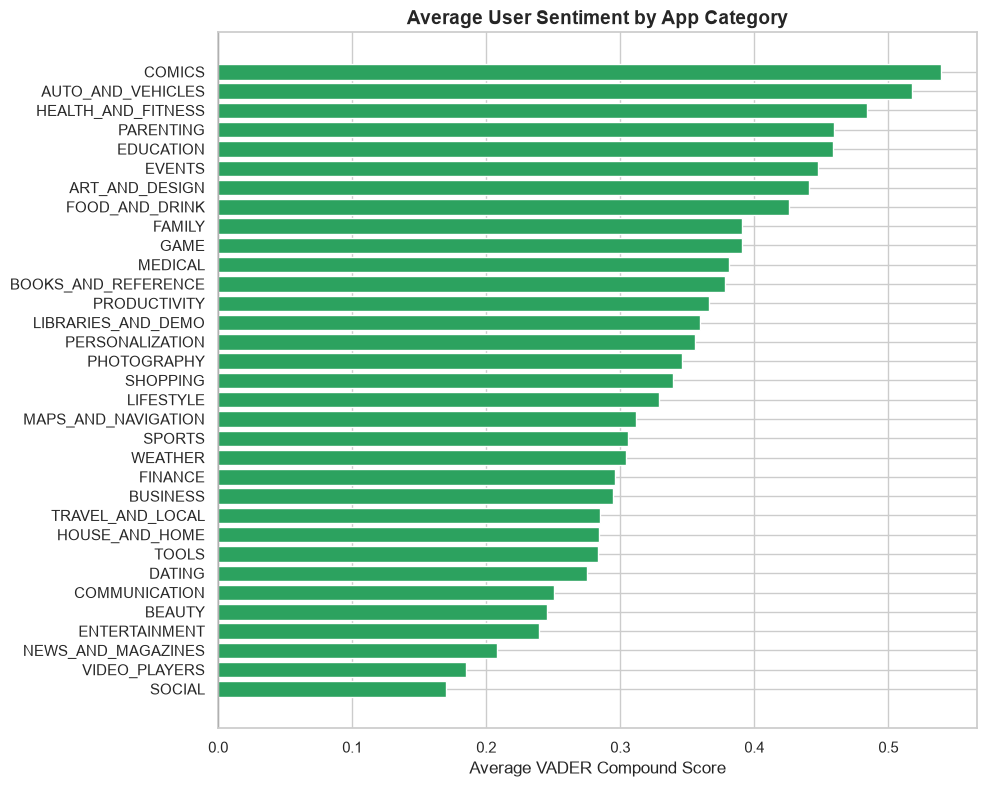

Most positive categories:
                    avg_compound  pct_positive  n_reviews
Category                                                 
COMICS                      0.54         86.67         45
AUTO_AND_VEHICLES           0.52         82.33        283
HEALTH_AND_FITNESS          0.48         78.47       1621
PARENTING                   0.46         73.44        256
EDUCATION                   0.46         77.65        519

Most negative (least positive) categories:
                    avg_compound  pct_positive  n_reviews
Category                                                 
BEAUTY                      0.24         60.25        317
ENTERTAINMENT               0.24         58.92        701
NEWS_AND_MAGAZINES          0.21         57.57        733
VIDEO_PLAYERS               0.18         56.75        326
SOCIAL                      0.17         55.07        661


In [30]:
app_categories = apps[['App', 'Category']].drop_duplicates(subset='App')
reviews_cat = reviews.merge(app_categories, on='App', how='left').dropna(subset=['Category'])

# require a minimum number of reviews per category for a meaningful average
min_reviews = 40
cat_review_counts = reviews_cat['Category'].value_counts()
valid_cats = cat_review_counts[cat_review_counts >= min_reviews].index

cat_sentiment = reviews_cat[reviews_cat['Category'].isin(valid_cats)].groupby('Category').agg(
    avg_compound=('vader_compound', 'mean'),
    pct_positive=('vader_sentiment', lambda s: (s == 'Positive').mean() * 100),
    n_reviews=('vader_compound', 'size')
).sort_values('avg_compound', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2ca25f' if v > 0 else '#de2d26' for v in cat_sentiment['avg_compound']]
ax.barh(cat_sentiment.index[::-1], cat_sentiment['avg_compound'][::-1], color=colors[::-1])
ax.set_xlabel('Average VADER Compound Score')
ax.set_title('Average User Sentiment by App Category', fontsize=14, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print("Most positive categories:")
print(cat_sentiment.head(5)[['avg_compound', 'pct_positive', 'n_reviews']].round(2))
print("\nMost negative (least positive) categories:")
print(cat_sentiment.tail(5)[['avg_compound', 'pct_positive', 'n_reviews']].round(2))


**Observation:** Categories like `EVENTS`, `AUTO_AND_VEHICLES`, `HEALTH_AND_FITNESS`, `EDUCATION` and `BEAUTY` tend to see the happiest users, while `SOCIAL`, `VIDEO_PLAYERS`, `NEWS_AND_MAGAZINES`, `ENTERTAINMENT` and `DATING` skew more negative ,likely reflecting more frequent bugs, ads, content moderation complaints, and higher user expectations in these high-engagement categories.

#### Interactive Visualisation (Plotly)

An interactive bubble chart: each bubble is a category, sized by number of apps, positioned by average rating vs. average sentiment, and coloured by estimated market saturation. Hover over a bubble to see the details.

In [31]:
cat_summary = apps.groupby('Category').agg(
    n_apps=('App', 'size'),
    avg_rating=('Rating', 'mean'),
    avg_installs=('Installs', 'mean'),
    pct_free=('Type', lambda s: (s == 'Free').mean() * 100)
).reset_index()

sentiment_join = cat_sentiment.reset_index()[['Category', 'avg_compound', 'pct_positive']]
cat_summary = cat_summary.merge(sentiment_join, on='Category', how='inner')
cat_summary = cat_summary[cat_summary['n_apps'] >= 15]

fig = px.scatter(
    cat_summary,
    x='avg_rating', y='avg_compound',
    size='n_apps', color='pct_positive',
    hover_name='Category',
    size_max=55,
    color_continuous_scale='Viridis',
    labels={
        'avg_rating': 'Average App Rating',
        'avg_compound': 'Average Review Sentiment (VADER compound)',
        'pct_positive': '% Positive Reviews',
        'n_apps': 'Number of Apps'
    },
    title='Category Landscape: App Rating vs. Review Sentiment (bubble size = # apps)'
)
fig.update_layout(
    height=600,
    template='plotly_white',
    title_font_size=16,
    coloraxis_colorbar=dict(title='% Positive'),
)
fig.update_traces(marker=dict(line=dict(width=1, color='DarkSlateGrey')))

# Self-contained HTML embed so it renders reliably in any notebook viewer / exported HTML
html_str = fig.to_html(full_html=False, include_plotlyjs='cdn')
display(HTML(html_str))

# Also save a standalone interactive file
fig.write_html('interactive_category_explorer.html', include_plotlyjs='cdn')
print("Saved standalone interactive chart to interactive_category_explorer.html")



Saved standalone interactive chart to interactive_category_explorer.html


> **Note on viewing this chart:** GitHub's built-in notebook preview strips JavaScript for security reasons, so the interactive chart above will appear blank if you're reading this on github.com. To interact with it (hover, zoom, pan):
> - Open **`interactive_category_explorer.html`** directly (double-click it locally, or view it via GitHub Pages / raw.githack.com), **or**
> - View this notebook through [nbviewer.org](https://nbviewer.org/) by pasting in the GitHub URL, **or**
> - Clone the repo and open the notebook in Jupyter/JupyterLab/Colab.
>
> A static snapshot (same data) is included below so the chart is still visible on GitHub either way.

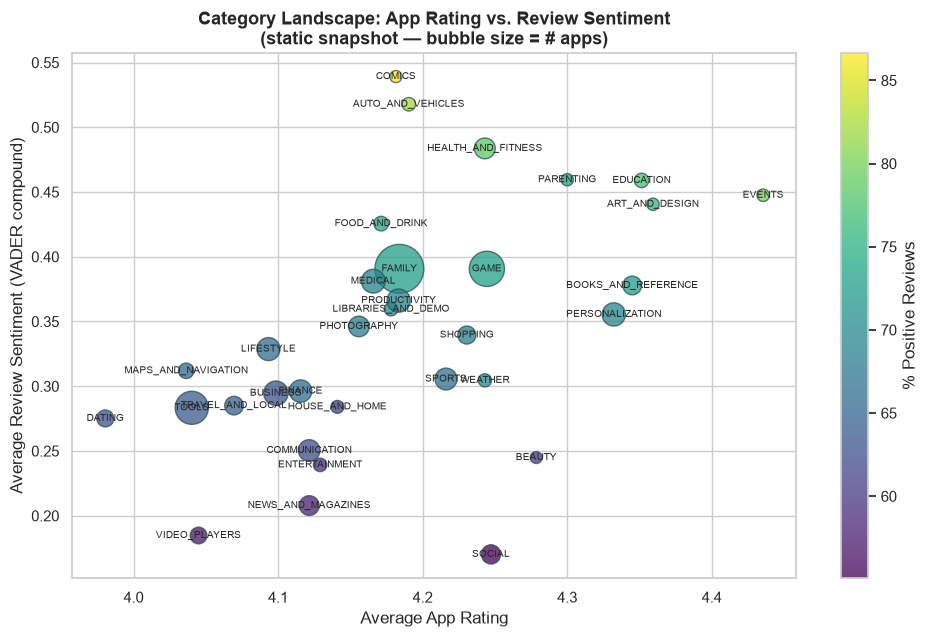

In [32]:
# Static (matplotlib) equivalent of the interactive chart above, for GitHub's non-JS notebook preview
fig2, ax = plt.subplots(figsize=(10, 6.5))
sizes = (cat_summary['n_apps'] / cat_summary['n_apps'].max()) * 1200 + 40
sc = ax.scatter(cat_summary['avg_rating'], cat_summary['avg_compound'],
                 s=sizes, c=cat_summary['pct_positive'], cmap='viridis',
                 alpha=0.75, edgecolors='DarkSlateGrey', linewidths=1)
for _, row in cat_summary.iterrows():
    ax.annotate(row['Category'], (row['avg_rating'], row['avg_compound']),
                fontsize=7, ha='center', va='center')
ax.set_xlabel('Average App Rating')
ax.set_ylabel('Average Review Sentiment (VADER compound)')
ax.set_title('Category Landscape: App Rating vs. Review Sentiment\n(static snapshot \u2014 bubble size = # apps)',
             fontsize=13, fontweight='bold')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('% Positive Reviews')
plt.tight_layout()
plt.savefig('static_preview_category_landscape.png', dpi=150)
plt.show()


**How to read this chart:** categories in the upper-right (high app rating *and* high review sentiment) are the healthiest ecosystems for both quality and user happiness. Categories in the lower-left combine mediocre ratings with grumpier reviewers — a signal that user expectations there are hard to meet. Bubble size shows how crowded (saturated) each category already is.

#### Conclusion: 3 Data-Driven Insights for a Developer Planning a New App

**1. Skip the overcrowded categories unless you have a truly unique angle.**

FAMILY, GAME, and TOOLS dominate the Play Store, which means your app will drown in a sea of competitors. Smaller categories like EVENTS, BEAUTY, COMICS, and PARENTING are much easier to rank in and they often have surprisingly happy, engaged users. Just make sure people actually want what you're building.


**2. Don't obsess over making your app size small or charging upfront.**
Over 90% of apps are free, and users don't seem to care much about file size. Focus your energy on features, marketing, and regular updates instead of shaving off megabytes. If you want to make money, in-app purchases or a freemium model fits what users already expect,paid downloads are a tough sell.



**3. High-traffic categories come with high stress.**
SOCIAL, VIDEO_PLAYERS, ENTERTAINMENT, NEWS, and DATING apps get downloaded a lot, but users in these spaces are also the quickest to leave angry reviews. If you go this route, plan for fast customer support, careful ad placement, and rapid bug fixes. If you prefer a calmer launch, EDUCATION or BOOKS_AND_REFERENCE offers a smaller but more forgiving audience.